# Instructor Effectiveness Modeling

## Problem Understanding

#### I have to work with a EdTech platform, courses are run over this platform over multiple batches by different instructor. My goal is to find Instructor effectiveness from available metrices

#### ---------------------------------------------------------------------------------------------------------------------------------------------------

## Loading Necessary Libraries

In [414]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

## Loading Dataset

In [415]:
df = pd.read_csv("instructor_effectiveness_dataset_2000_rows.csv")
df

,batch_id,instructor_id,course_id,completion_rate,avg_score_improvement,avg_quiz_score,dropout_rate,avg_watch_time,assignment_submission_rate,forum_activity_rate,avg_feedback_score,feedback_response_rate
0,B_1861,I_044,C_01,0.300000,14.225955,73.546528,0.647423,0.774572,0.790918,0.108414,3.766211,0.533193
1,B_0354,I_119,C_06,0.657220,22.871110,77.312331,0.425098,0.494936,0.998566,0.280550,5.000000,0.734087
2,B_1334,I_050,C_03,0.300000,16.087517,79.563687,0.700000,0.977901,0.807298,0.207013,3.517386,0.681433
3,B_0906,I_024,C_21,0.639507,24.260687,99.295316,0.334657,0.846515,0.544555,0.306395,4.207578,1.000000
4,B_1290,I_001,C_08,0.527302,31.081556,99.393425,0.521099,0.917450,0.865885,0.252289,4.426230,0.696710
...,...,...,...,...,...,...,...,...,...,...,...,...
1995,B_1131,I_047,C_17,0.589309,19.227979,46.242023,0.433437,0.848756,0.641781,0.261656,4.339478,0.643116
1996,B_1295,I_037,C_25,0.980000,36.737265,93.249093,0.103561,1.000000,0.688175,0.375195,4.912936,0.959988
1997,B_0861,I_033,C_06,0.531447,24.907878,83.990693,0.512266,0.918924,0.598276,0.271701,4.211113,0.773437
1998,B_1460,I_069,C_10,0.641025,22.395362,80.044231,0.317231,0.558183,0.575629,0.135500,4.182141,0.962627


## Doing Basic Understanding of Dataset

### Checking datatype of columns

In [416]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   batch_id                    2000 non-null   object 
 1   instructor_id               2000 non-null   object 
 2   course_id                   2000 non-null   object 
 3   completion_rate             2000 non-null   float64
 4   avg_score_improvement       2000 non-null   float64
 5   avg_quiz_score              2000 non-null   float64
 6   dropout_rate                2000 non-null   float64
 7   avg_watch_time              2000 non-null   float64
 8   assignment_submission_rate  2000 non-null   float64
 9   forum_activity_rate         2000 non-null   float64
 10  avg_feedback_score          2000 non-null   float64
 11  feedback_response_rate      2000 non-null   float64
dtypes: float64(9), object(3)
memory usage: 187.6+ KB


### Checking rows and columns of dataset

In [417]:
df.shape

(2000, 12)

### Checking all columns

In [418]:
df.columns

Index(['batch_id', 'instructor_id', 'course_id', 'completion_rate',
       'avg_score_improvement', 'avg_quiz_score', 'dropout_rate',
       'avg_watch_time', 'assignment_submission_rate', 'forum_activity_rate',
       'avg_feedback_score', 'feedback_response_rate'],
      dtype='object')

### Understanding data deeply

In [419]:
df.describe()

,completion_rate,avg_score_improvement,avg_quiz_score,dropout_rate,avg_watch_time,assignment_submission_rate,forum_activity_rate,avg_feedback_score,feedback_response_rate
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,0.602808,27.035844,77.956126,0.394883,0.776515,0.753188,0.250300,4.207134,0.736519
std,0.159667,5.716641,10.695618,0.162747,0.145231,0.148058,0.100640,0.419209,0.149412
min,0.300000,6.159240,40.386725,0.020000,0.287440,0.251111,0.000000,2.639915,0.259935
25%,0.489260,23.124673,70.897590,0.280035,0.675076,0.652110,0.179845,3.918986,0.633293
50%,0.603091,26.938629,78.020567,0.394820,0.780330,0.756380,0.249771,4.205989,0.737213
75%,0.712797,30.885600,85.444286,0.511432,0.894242,0.856458,0.319204,4.503437,0.845876
max,0.980000,40.000000,100.000000,0.700000,1.000000,1.000000,0.641111,5.000000,1.000000


# Insights
#### 1. All the datatypes of columns are fine.
#### 2. The shape of data is 2000 rows and 12 columns.
#### 3. The average completion rate is around 60%, while the dropout rate is around 40%. 
#### 4. The score improvement is almost by 27, where as Average quiz score is 78.
#### 5. Learners watch about 77% of videos and submit 75% of assignments, but forum participation is relatively low (~25%).
#### 6. Average feedback score is near to 4 while response rate is 73%.

## Finding Duplicates in Dataset

In [420]:
df.duplicated().sum()   #There are 0 duplicates

np.int64(0)

## Finding Null Values

In [421]:
df.isnull().sum()   #There are no null Values

batch_id                      0
instructor_id                 0
course_id                     0
completion_rate               0
avg_score_improvement         0
avg_quiz_score                0
dropout_rate                  0
avg_watch_time                0
assignment_submission_rate    0
forum_activity_rate           0
avg_feedback_score            0
feedback_response_rate        0
dtype: int64

# Insights
#### 1. There are 0 duplicates and 0 null values in Dataset

#### ---------------------------------------------------------------------------------------------------------------------------------------------------

# Exploratory Data Analysis (EDA)

## 1. Learner Outcome Metrics (Histogram for the following)

- completion_rate
- dropout_rate
- avg_quiz_score
- avg_feedback_score

### The thinking behind this is to understand each feature of learner properly before correlating it with other features

### Histogram of Completion_rate

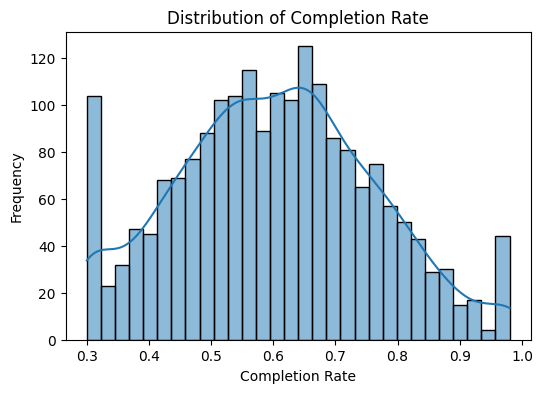

In [422]:
plt.figure(figsize=(6,4))
sns.histplot(df["completion_rate"], bins=30, kde=True)
plt.title("Distribution of Completion Rate")
plt.xlabel("Completion Rate")
plt.ylabel("Frequency")
plt.show()

### Understanding
- Most batches have completion rates between 0.5 and 0.75.
- Very few batches have completion rates above 0.9, indicating only a small number of highly successful batches.

### Histogram of Dropout_rate

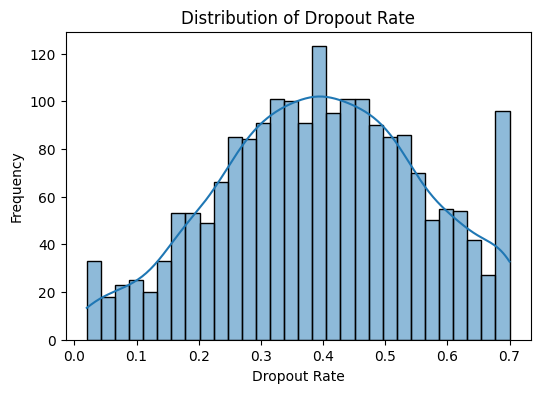

In [423]:
plt.figure(figsize=(6,4))
sns.histplot(df["dropout_rate"], bins=30, kde=True)
plt.title("Distribution of Dropout Rate")
plt.xlabel("Dropout Rate")
plt.ylabel("Frequency")
plt.show()

### Understanding 
- Most dropout rates lie between 0.3 and 0.5.
- High dropout (>0.6) occurs in relatively fewer batches.

### Histogram of avg_quiz_score

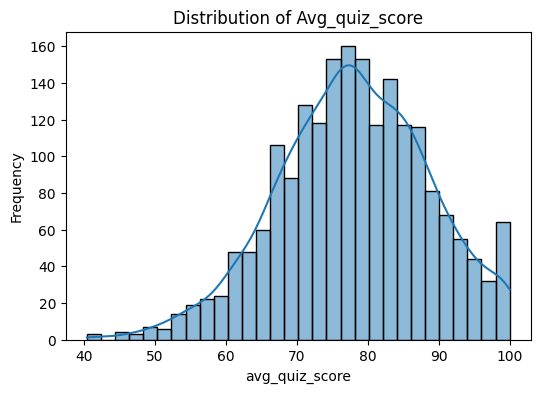

In [424]:
plt.figure(figsize=(6,4))
sns.histplot(df["avg_quiz_score"], bins=30, kde=True)
plt.title("Distribution of Avg_quiz_score")
plt.xlabel("avg_quiz_score")
plt.ylabel("Frequency")
plt.show()

### Understanding 
- Quiz scores are mostly between 70 and 85, showing generally good performance.

### Histogram of avg_feedback_score

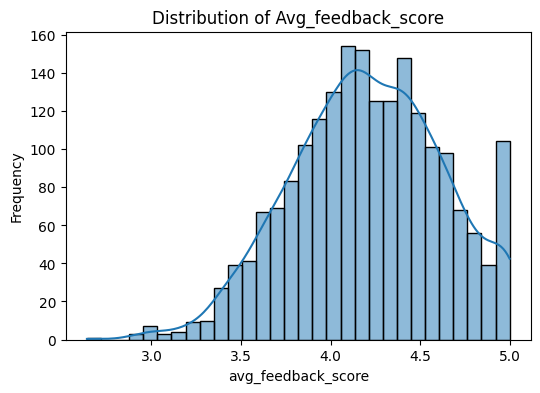

In [425]:
plt.figure(figsize=(6,4))
sns.histplot(df["avg_feedback_score"], bins=30, kde=True)
plt.title("Distribution of Avg_feedback_score")
plt.xlabel("avg_feedback_score")
plt.ylabel("Frequency")
plt.show()

### Understanding 
- Most feedback scores are between 3.8 and 4.5, indicating learners are generally satisfied.

## 2. Engagement Metrics (Histogram for the following)
- avg_watch_time
- assignment_submission_rate
- forum_activity_rate

### The thinking behind this is to understand the batch engagement during lectures

### Histogram for Average watch time

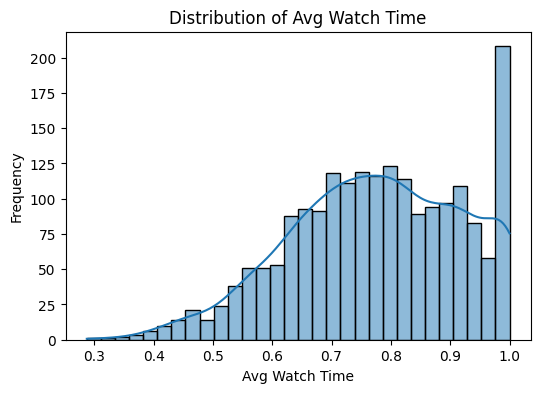

In [426]:
plt.figure(figsize=(6,4))
sns.histplot(df["avg_watch_time"], bins=30, kde=True)
plt.title("Distribution of Avg Watch Time")
plt.xlabel("Avg Watch Time")
plt.ylabel("Frequency")
plt.show()

### Understanding
- Most batches have watch time between 0.7 and 0.9, meaning learners watch a large portion.

### Histogram for Assignment submission rate

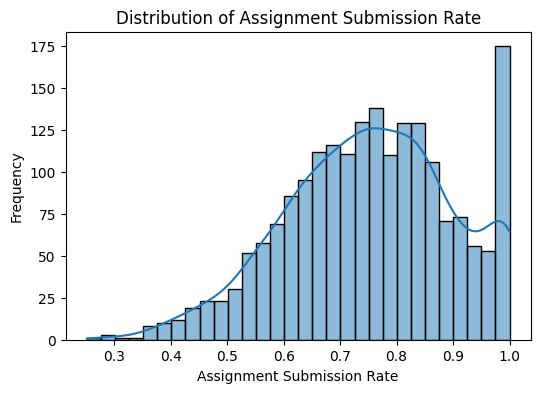

In [427]:
plt.figure(figsize=(6,4))
sns.histplot(df["assignment_submission_rate"], bins=30, kde=True)
plt.title("Distribution of Assignment Submission Rate")
plt.xlabel("Assignment Submission Rate")
plt.ylabel("Frequency")
plt.show()

### Understanding
- Most batches have assignment submission rates between 0.7 and 0.9.
- This suggests learners are actively completing course assignments.

### Histogram for Forum Activity Rate

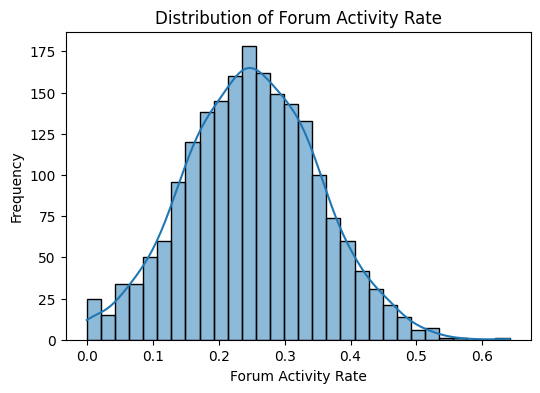

In [428]:
plt.figure(figsize=(6,4))
sns.histplot(df["forum_activity_rate"], bins=30, kde=True)
plt.title("Distribution of Forum Activity Rate")
plt.xlabel("Forum Activity Rate")
plt.ylabel("Frequency")
plt.show()

### Understanding
- Forum activity is much lower compared to other engagement metrics.
- Most values lie between 0.15 and 0.35, indicating that discussion forum participation is relatively limited.

## 3. Create correlation heatmap for all numeric columns.

### The thinking behind this is to understand how numeric columns are behaving with each other

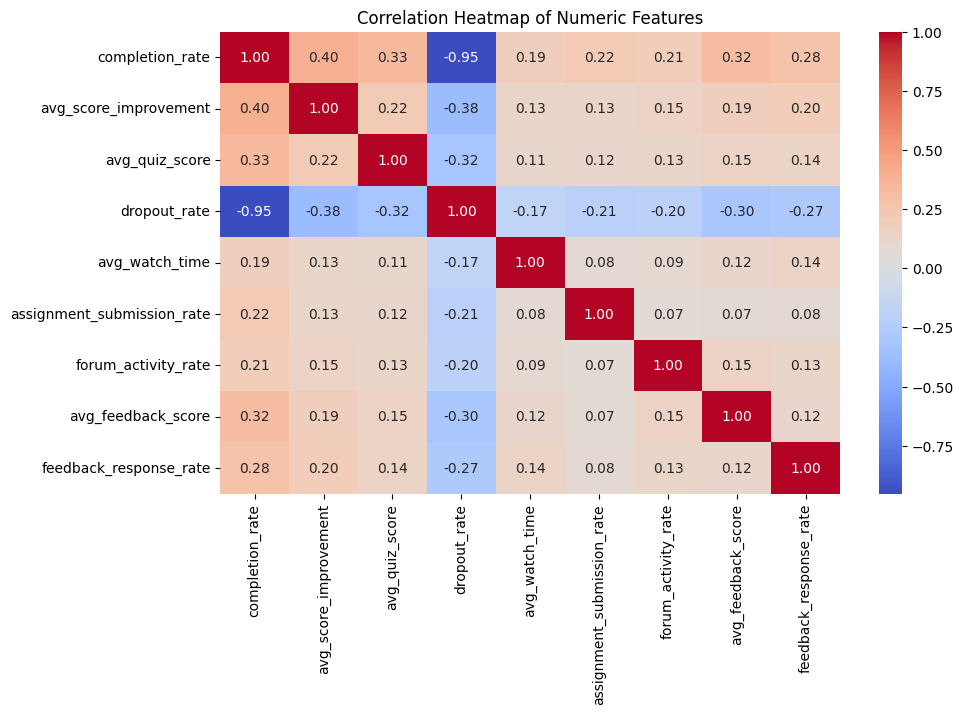

In [429]:
plt.figure(figsize=(10,6))
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap of Numeric Features")
plt.show()

### Understanding
- completion_rate and dropout_rate have very strong negative correlation (-0.95)
meaning when completion increases, dropout decreases.
- avg_score_improvement moderately correlates with completion_rate (0.40)
Meaning better learning improvement leads to higher completion.
- Engagement metrics have weak correlations with outcomes
Meaning watch time, assignments, forum activity only slightly affect completion.

## 4. Plotting Relationships

### i) Completion Rate vs Dropout Rate

### The thinking behind this is according to business mindset as for business completion and dropout matters most. If dropout is more then there is problem

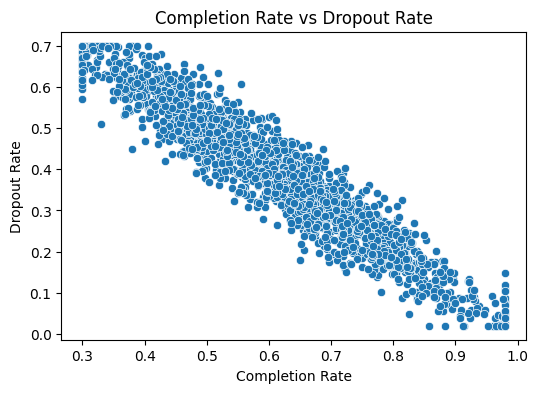

In [430]:
plt.figure(figsize=(6,4))
sns.scatterplot(x=df["completion_rate"], y=df["dropout_rate"])
plt.title("Completion Rate vs Dropout Rate")
plt.xlabel("Completion Rate")
plt.ylabel("Dropout Rate")
plt.show()

### Understanding
- This clearly tells us that when completion rate increases than dropout rate decreases

### ii) avg_quiz_score vs avg_score_improvement

### This relationship tells us how much scores are going up and how is improvement going along with it.

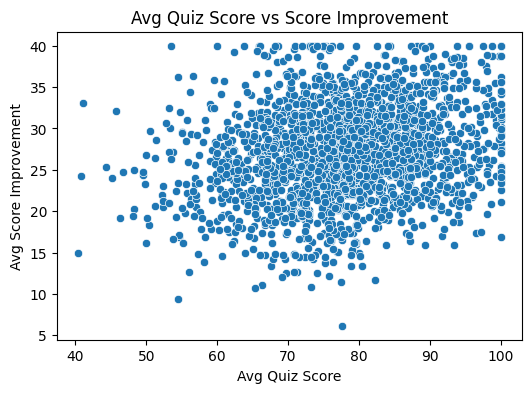

In [431]:
plt.figure(figsize=(6,4))
sns.scatterplot(x=df["avg_quiz_score"], y=df["avg_score_improvement"])
plt.title("Avg Quiz Score vs Score Improvement")
plt.xlabel("Avg Quiz Score")
plt.ylabel("Avg Score Improvement")
plt.show()

### Understanding
- Batches with higher quiz scores generally tend to have higher score improvements, although the relationship is not very strong.

### iii) avg_watch_time vs completion_rate

### This tells us that does watching more lectures lead to higher course completion rates?

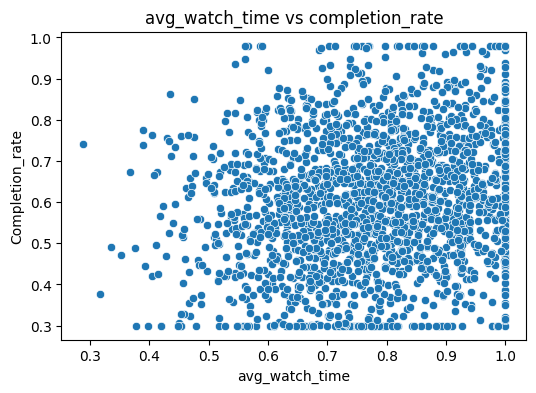

In [432]:
plt.figure(figsize=(6,4))
sns.scatterplot(x=df["avg_watch_time"], y=df["completion_rate"])
plt.title("avg_watch_time vs completion_rate")
plt.xlabel("avg_watch_time")
plt.ylabel("Completion_rate")
plt.show()

### Understanding
- Batches where learners watch more course videos tend to have slightly higher completion rates.
- However, the relationship is not very strong, suggesting that watching videos alone may not fully determine course completion.

#### ---------------------------------------------------------------------------------------------------------------------------------------------------

# Define Instructor Effectiveness

## So to firstly to define instructor effectiveness we will work in 3 parts only
- Learner Outcome Metrices
- Engagment Metrices 
- Instructor Quality

## 1) Learner Outcome Metrices
This consist of 4 columns
completion_rate,dropout_rate,avg_score_improvement,avg_quiz_score

i) In this avg_quiz_score has values between 40-100 while others are in 0.3-1, so in ML this feature will dominate more so we need to use MinMax Scaler to bring its value down
ii) About drop_out rate in heatmap we saw its negative relationship with completion_rate when completion goes up drop_out goes down which is right logically
But here if dropout rate goes up it is problem and machine might feel it is good but its not, so we are subracting it by 1, to flip things.

## 2) Engagement Metrics
This consists of 3 columns: avg_watch_time, assignment_submission_rate, forum_activity_rate

- avg_watch_time — most batches between 0.7 and 0.9
- assignment_submission_rate — most batches between 0.7 and 0.9
- forum_activity_rate — most values between 0.15 and 0.35, much lower than the other two

#### All three engagement metrics have weak correlations with completion_rate (around 0.19–0.22)

Since forum activity is low across the board and weakly correlated with outcomes, it should get the lowest weight. Watch time and assignment submission are stronger signals of engagement so they get higher weight. Also — all three are already in 0–1 range from your histograms, but after MinMaxScaler they'll be perfectly normalized anyway.

## 3) Instructor Quality Metrics
This consists of 2 columns: avg_feedback_score, feedback_response_rate

- avg_feedback_score has a moderate correlation with completion_rate
- feedback_response_rate is weaker too.

## Learning Outcome will be weighted highest at 40% because completion and learning are the primary goals of any course. Engagement will be weighted 35% as it represents active participation which drives outcomes. Instructor Quality will be weighted 25% as feedback is subjective and lagging. A student fills out feedback after the course ends. It matters, but it's downstream.

### Importing MinMax Scaler

In [433]:
from sklearn.preprocessing import MinMaxScaler

### Taking columns to do MinMax Scaling

In [434]:
columns_to_scale = ['completion_rate', 'avg_score_improvement', 'avg_quiz_score','avg_watch_time', 'assignment_submission_rate', 'forum_activity_rate',
'avg_feedback_score', 'feedback_response_rate', 'dropout_rate']

### Doing MinMax Scaling

In [435]:
scaler = MinMaxScaler()
df_scaled = df.copy()
df_scaled[columns_to_scale] = scaler.fit_transform(df[columns_to_scale])

### Flipping the dropout_rate as mentioned above

In [436]:
df_scaled['dropout_rate_inv'] = 1 - df_scaled['dropout_rate']
df_scaled['dropout_rate_inv'] = df_scaled['dropout_rate_inv'].clip(lower=0)

## Checking Scaled Data

In [437]:
df_scaled[['completion_rate', 'dropout_rate', 'dropout_rate_inv', 'avg_quiz_score']].head()

,completion_rate,dropout_rate,dropout_rate_inv,avg_quiz_score
0,0.000000,0.922681,0.077319,0.556249
1,0.525324,0.595732,0.404268,0.619419
2,0.000000,1.000000,0.000000,0.657185
3,0.499274,0.462731,0.537269,0.988179
4,0.334267,0.736911,0.263089,0.989825


## Making Pillar Scores
Based on Importance SubPillars are marked

A) Learning pillar
1. completion_rate = 0.3
2. dropout_rate_inv = 0.25
3. avg_score_improvement = 0.25
4. avg_quiz_score = 0.2

Total = 1

B) Engagement pillar:
1. avg_watch_time = 0.4
2. assignment_submission_rate = 0.4
3. forum_activity_rate = 0.2

Total = 1

C) Quality pillar:
1. avg_feedback_score = 0.6
2. feedback_response_rate = 0.4

Total = 1

In [438]:
#Learning Pillar
df_scaled['pillar_learning'] = (df_scaled['completion_rate']       * 0.30 + df_scaled['dropout_rate_inv']      
* 0.25 + df_scaled['avg_score_improvement'] * 0.25 + df_scaled['avg_quiz_score']        * 0.20)

#Engagment Pillar
df_scaled['pillar_engagement'] = (df_scaled['avg_watch_time']             * 0.40 + df_scaled['assignment_submission_rate'] * 0.40 +
df_scaled['forum_activity_rate']        * 0.20)

#Quality Pillar
df_scaled['pillar_quality'] = ( df_scaled['avg_feedback_score']     * 0.60 + df_scaled['feedback_response_rate'] * 0.40)

## Final Scoring combining all 3 pillars

In [439]:
df_scaled['effectiveness_score'] = ( df_scaled['pillar_learning']   * 0.40 + df_scaled['pillar_engagement'] 
* 0.35 + df_scaled['pillar_quality']    * 0.25)

In [440]:
df_scaled

,batch_id,instructor_id,course_id,completion_rate,avg_score_improvement,avg_quiz_score,dropout_rate,avg_watch_time,assignment_submission_rate,forum_activity_rate,avg_feedback_score,feedback_response_rate,dropout_rate_inv,pillar_learning,pillar_engagement,pillar_quality,effectiveness_score
0,B_1861,I_044,C_01,0.000000,0.238373,0.556249,0.922681,0.683637,0.720811,0.169103,0.477227,0.369235,0.077319,0.190173,0.595600,0.434030,0.393037
1,B_0354,I_119,C_06,0.525324,0.493839,0.619419,0.595732,0.291198,0.998085,0.437599,1.000000,0.640690,0.404268,0.506008,0.603233,0.856276,0.627604
2,B_1334,I_050,C_03,0.000000,0.293382,0.657185,1.000000,0.968987,0.742683,0.322898,0.371797,0.569542,0.000000,0.204783,0.749247,0.450895,0.456873
3,B_0906,I_024,C_21,0.499274,0.534901,0.988179,0.462731,0.784601,0.391839,0.477913,0.664240,1.000000,0.537269,0.615461,0.566159,0.798544,0.643976
4,B_1290,I_001,C_08,0.334267,0.736459,0.989825,0.736911,0.884150,0.820915,0.393519,0.756886,0.590184,0.263089,0.548132,0.760730,0.690205,0.658060
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,B_1131,I_047,C_17,0.425454,0.386183,0.098221,0.607995,0.787746,0.521666,0.408129,0.720128,0.517766,0.392005,0.341827,0.605391,0.639183,0.508414
1996,B_1295,I_037,C_25,1.000000,0.903586,0.886755,0.122884,1.000000,0.583616,0.585226,0.963110,0.945935,0.877116,0.922526,0.750492,0.956240,0.870743
1997,B_0861,I_033,C_06,0.340363,0.554025,0.731447,0.723920,0.886218,0.463573,0.423797,0.665738,0.693860,0.276080,0.455925,0.624676,0.676987,0.570253
1998,B_1460,I_069,C_10,0.501507,0.479780,0.665246,0.437105,0.379958,0.433333,0.211351,0.653462,0.949500,0.562895,0.544170,0.367586,0.771877,0.539293


## Now there are 2000 rows with multiple instructor now we want 1 row 1 instructor

In [441]:
instructor_df = df_scaled.groupby('instructor_id').agg(effectiveness_score=('effectiveness_score', 'mean'),num_batches=('batch_id', 'count')).reset_index()
print(f"Total instructors: {len(instructor_df)}")

Total instructors: 120


#### To aggregate i have used mean to find out actual average effectiveness of instructor as 1 good/bad batch should not affect the answer, In this analysis we are not handling instructors with few or more batches separately. We are taking a simple mean across all batches equally. This is a limitation 

In [442]:
instructor_df

,instructor_id,effectiveness_score,num_batches
0,I_001,0.557370,25
1,I_002,0.685658,20
2,I_003,0.701885,18
3,I_004,0.522494,17
4,I_005,0.752879,19
...,...,...,...
115,I_116,0.558837,17
116,I_117,0.647219,19
117,I_118,0.747297,19
118,I_119,0.598473,19


## Converting this score into effectiveness tiers,
● Low
● Medium
● High

In [443]:
print(instructor_df['effectiveness_score'].describe())

count    120.000000
mean       0.590859
std        0.092872
min        0.360753
25%        0.529054
50%        0.592152
75%        0.642504
max        0.832791
Name: effectiveness_score, dtype: float64


### Above me found out that minimum clustering is 0.36 maximum is 0.83 and mean is 0.59

In [444]:
low_25  = instructor_df['effectiveness_score'].quantile(0.25)
high_75 = instructor_df['effectiveness_score'].quantile(0.75)

### We use 25th and 75th percentile values directly from describe()

In [445]:
#function to check which zone the score falls in, return the label
def assign_tier(score):
    if score < low_25:
        return 'Low'
    elif score < high_75:
        return 'Medium'
    else:
        return 'High'

# Build a Machine Learning Model

## So the logic behind this since we have 120 instructors and joining them will the 2000 row data above is not possible, so for each instructor we joined their avg scores across feilds

In [446]:
instructor_df = df_scaled.groupby('instructor_id').agg(effectiveness_score=('effectiveness_score', 'mean'),pillar_learning=('pillar_learning', 'mean'),
    pillar_engagement=('pillar_engagement', 'mean'),pillar_quality=('pillar_quality', 'mean'),
    completion_rate=('completion_rate', 'mean'),avg_quiz_score=('avg_quiz_score', 'mean'),
    avg_score_improvement=('avg_score_improvement', 'mean'),dropout_rate_inv=('dropout_rate_inv', 'mean'),
    avg_watch_time=('avg_watch_time', 'mean'),assignment_submission_rate=('assignment_submission_rate', 'mean'),
    forum_activity_rate=('forum_activity_rate', 'mean'),avg_feedback_score=('avg_feedback_score', 'mean'),
    feedback_response_rate=('feedback_response_rate', 'mean'),num_batches=('batch_id', 'count')
).reset_index()

In [447]:
instructor_df['tier'] = instructor_df['effectiveness_score'].apply(assign_tier) #creating new column by executing the function

In [448]:
instructor_df['tier']

0      Medium
1        High
2        High
3         Low
4        High
        ...  
115    Medium
116      High
117      High
118    Medium
119    Medium
Name: tier, Length: 120, dtype: object

In [449]:
instructor_df   # the new Dataframe

,instructor_id,effectiveness_score,pillar_learning,pillar_engagement,pillar_quality,completion_rate,avg_quiz_score,avg_score_improvement,dropout_rate_inv,avg_watch_time,assignment_submission_rate,forum_activity_rate,avg_feedback_score,feedback_response_rate,num_batches,tier
0,I_001,0.557370,0.472463,0.598099,0.636201,0.358658,0.646055,0.605253,0.337363,0.672327,0.635317,0.375209,0.668547,0.587682,25,Medium
1,I_002,0.685658,0.672646,0.678564,0.716409,0.633639,0.693645,0.709411,0.665891,0.771799,0.698745,0.451731,0.721621,0.708591,20,High
2,I_003,0.701885,0.691886,0.672773,0.758642,0.688892,0.691192,0.703843,0.684076,0.745203,0.705706,0.462047,0.766972,0.746147,18,High
3,I_004,0.522494,0.374885,0.625367,0.614648,0.232836,0.625592,0.495047,0.224616,0.709681,0.677277,0.352917,0.608662,0.623627,17,Low
4,I_005,0.752879,0.798424,0.752442,0.680617,0.823158,0.762270,0.780993,0.815098,0.785317,0.835679,0.520220,0.662095,0.708399,19,High
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
115,I_116,0.558837,0.511804,0.570634,0.617572,0.436920,0.641695,0.587176,0.422379,0.665276,0.546923,0.428773,0.615043,0.621366,17,Medium
116,I_117,0.647219,0.616013,0.667459,0.668813,0.576052,0.680971,0.658131,0.569881,0.709879,0.751956,0.413625,0.705874,0.613221,19,High
117,I_118,0.747297,0.765050,0.662242,0.837968,0.765813,0.783132,0.782416,0.732303,0.682022,0.772042,0.403079,0.848305,0.822463,19,High
118,I_119,0.598473,0.518732,0.619866,0.696108,0.442054,0.676846,0.561456,0.441529,0.683998,0.688609,0.354117,0.709927,0.675381,19,Medium


### Assigning Values to X and y for ML

In [450]:
X = instructor_df.drop(columns=['instructor_id', 'effectiveness_score', 'tier']) 
y = instructor_df['tier']

#### Here i am dropping 3 features from X because i) Instructor_id doesnt make sense, ii) effectiveness_score is the basic judgement it is coz leakage and tier is the y column

In [451]:
print(f"The shape of X is {X.shape}")
print(f"The y Value counts are:\n {y.value_counts()}")

The shape of X is (120, 13)
The y Value counts are:
 tier
Medium    60
High      30
Low       30
Name: count, dtype: int64


## Now the core ML part
### 1. I will be making 3 ML models 
        i) Random Forest
        ii) Logistic Regression
        iii) Gradient Boosting

i) Random Forest - This model handles non-linear relationship well and in eda we saw that there are many non-linear relationships in data 

ii) Logistic Regression - Used by me in past, simple (will be using it for comparision)

iii) Gradient Boosting - Learns from past errors of trees



### In train test split i will be splitting data into 80/20 - 80% will be training and 20% will be testing, testing model on training data is just copy-paste


### Importing necessary libraries

In [452]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score

In [453]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)  #training and testing

In [454]:
print(f"Training samples: {len(X_train)}")
print(f"Testing samples:  {len(X_test)}")  #This is length of our training and testing data

Training samples: 96
Testing samples:  24


#### Now in this Dictionary we will write our models

In [455]:
models = {
    'Random Forest'       : RandomForestClassifier(n_estimators=100, random_state=42),
    'Logistic Regression' : LogisticRegression(max_iter=1000, random_state=42),
    'Gradient Boosting'   : GradientBoostingClassifier(n_estimators=100, random_state=42)
}

In [456]:
results = {}  #The output

In [457]:
for name, model in models.items():   #Running the loop to run all models
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    acc = accuracy_score(y_test, y_pred)         #accuracy score
    results[name] = acc

    
    print(f"\n{'='*40}")
    print(f"Model: {name}")
    print(f"Accuracy: {acc:.4f}")
    print(classification_report(y_test, y_pred))        #Printing the outcome


Model: Random Forest
Accuracy: 0.9583
              precision    recall  f1-score   support

        High       1.00      0.83      0.91         6
         Low       1.00      1.00      1.00         6
      Medium       0.92      1.00      0.96        12

    accuracy                           0.96        24
   macro avg       0.97      0.94      0.96        24
weighted avg       0.96      0.96      0.96        24


Model: Logistic Regression
Accuracy: 0.7917
              precision    recall  f1-score   support

        High       1.00      0.50      0.67         6
         Low       1.00      0.67      0.80         6
      Medium       0.71      1.00      0.83        12

    accuracy                           0.79        24
   macro avg       0.90      0.72      0.76        24
weighted avg       0.85      0.79      0.78        24


Model: Gradient Boosting
Accuracy: 0.8750
              precision    recall  f1-score   support

        High       0.86      1.00      0.92         6
  

### So we can see as per Accuracy score Random Forest is the best model followed by Gradient Boosting also the f1-score and recall of Random Forest is much better, gradient boosting lacks in precision

## Precision vs Recall
- Precision - out of all predicted HIGH how many were actually HIGH ; Recall -  of all actual High instructors, how many did we correctly identify.
- In EdTech company low recall matters as we want to first get rid of LOW instructor and with other metrices Random Forest Matches that perfectly

## Visual Comparision of Models

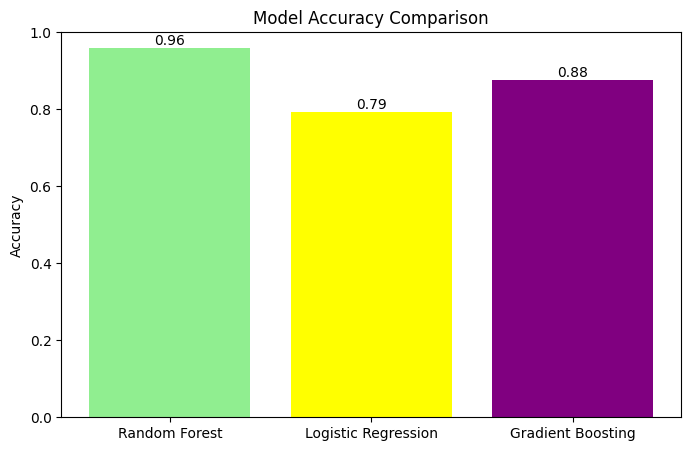

In [458]:
# Bar chart comparing all 3 accuracies
plt.figure(figsize=(8, 5))
plt.bar(results.keys(), results.values(), color=['lightgreen','yellow','purple'])
plt.title('Model Accuracy Comparison')
plt.ylabel('Accuracy')
plt.ylim(0, 1)
for i, (name, acc) in enumerate(results.items()):
    plt.text(i, acc + 0.01, f'{acc:.2f}', ha='center')
plt.show()

## Seeing the feature importance

In [459]:
if hasattr(best_model, 'feature_importances_'):
    importance_df = pd.DataFrame({'feature'   : X.columns,'importance': best_model.feature_importances_}).sort_values('importance', ascending=False)

importance_df

,feature,importance
6,dropout_rate_inv,0.282895
0,pillar_learning,0.202352
3,completion_rate,0.168479
2,pillar_quality,0.073313
5,avg_score_improvement,0.070726
4,avg_quiz_score,0.059099
1,pillar_engagement,0.055661
10,avg_feedback_score,0.046996
9,forum_activity_rate,0.010358
8,assignment_submission_rate,0.009933


## Understanding
- dropout_rate is 0.28 (Highest) it makes sense as the instructor whos student dropout are not effective in sign, and even EDA showed negative 
correlation. 
- Bottom 5 features are of least importance and in EDA we saw they contributed less.
- The completion rate is 3rd most important feature and it is totally important for teacher effectiveness
- Overall Improvement is taken as more important than quiz_score

## Confusion Matrix of 3 Models for better Understanding

In [460]:
from sklearn.metrics import confusion_matrix

for name, model in models.items():
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred, labels=['Low', 'Medium', 'High'])
    print(f"\nModel: {name}")
    print(f"         Pred:Low  Pred:Medium  Pred:High")
    print(f"Act:Low     {cm[0][0]}          {cm[0][1]}           {cm[0][2]}")
    print(f"Act:Medium  {cm[1][0]}          {cm[1][1]}           {cm[1][2]}")
    print(f"Act:High    {cm[2][0]}          {cm[2][1]}           {cm[2][2]}")
    print(f"{'='*45}")


Model: Random Forest
         Pred:Low  Pred:Medium  Pred:High
Act:Low     6          0           0
Act:Medium  0          12           0
Act:High    0          1           5

Model: Logistic Regression
         Pred:Low  Pred:Medium  Pred:High
Act:Low     4          2           0
Act:Medium  0          12           0
Act:High    0          3           3

Model: Gradient Boosting
         Pred:Low  Pred:Medium  Pred:High
Act:Low     5          1           0
Act:Medium  1          10           1
Act:High    0          0           6


### The Most important thing for a EdTech company is that their money is not lost, ie if model predicts a instructor as HIGH but it is low so it is loss for company, also predicting someone low who is actual high is wrong, So our model should be made in such way we avoid this things as much as possible

Predicting Low as High — Company gives this instructor more batches thinking they're great. Students suffer, company loses money and reputation.

Predicting High as Low — Company removes a good instructor. Talent loss.

### Interpretation of Confusion Matrix
1. Out of 24 Random Forest predicts 6 Low and in actual 6 are Low, it predicts 12 as medium and yes they are medium and for high it perfectly predicts them as well, only thing is it predicted 1 instructor medium which was high
2. Out of 24 Logistic Regression predicts 4 as low and they were actual low but the 2 instructor which were low it predicted them as medium which is a wrong signal, for medium is was perfect, and for high it predicted 3 proper but for rest 3 it didnt give designated result, so this model is not better than *random forest*
3. Out of 24 Gradient Boosting predicted 5 as low and it is fine but it flaged 1 row as medium which is bad than random forest, also for medium it predicted 10 properly but got wrong in 2, for High it is fine.
                                                                                                                                                     

### -------------------------------------------------------------------------------------------------------------------

## So for this project I will be using Random Forest model. As this model on basis of Dropout_rate, completion_rate, quiz_score, engagment_rate, improvement_rate and other factors performs better than other models. Also the confusion matrix for Random forest is the best as it signifies properly getting rid of LOW instructor and predicting HIGH also accuratley with almost 96% accuracy. In simple terms the instructor with LOW dropout rate as considered as better than others wit other metrices playing their part

#### -- In real world this system can be used as 
-  A early warning system, to understand about instructor.
-  Instructor evaluation after 2-3 batches
-  Assigning the best instructor to important/premium batches

### -------------------------------------------------------------------------------------------------------------------

## Mandatory Analysis Questions

### 1. Which features most influenced instructor effectiveness, and why?
- Answer - For our project the most important feature is dropout_rate which is 0.28 followed by completion rate and pillar_learning which are 0.17 and 0.2 respectively. This gives us a clear indication that for a instructor to be flagged as high most important thing would be to keep students engaged to complete the course. If they dropout then there is problem with instructor, 

## 2. Which variables could be misleading or confounded?
- Answer - In our Exploratory Data Analysis we saw a feature which was avg_watch_time, normal interpretation would be that if a person watches the lecture more
then there is more chance of completing the course. But in this data avg_watch_time didnt gaurentee the completion of course, students with watch time less than 0.65
also completed the course. Also in my interpretation avg_feedback is a feature of less importance as sometimes instructor get good feedback just because of
their good behaviour not due to teaching, this scenario is also vice versa — an instructor can get poor feedback simply because the course was hard, not because they taught badly.

## 3. How could this model fail in real-world usage?
- Answer - 1) We have dataset of 120 instructors only, this is a small dataset and machine has very less patterns to learn from.
           2) Take a example of a instructor who got 3 bd batches in start and the score of instructor are very low, but in future even if he/she teaches well the scores in past will affect their rating.

Blinding trusting on model should not be done 

## 4. What additional data would improve this analysis?
- Answer - Firstly the data given was about the batches and its overall metrices. The data of each student is also important as knowing specific student why they dropped out will give more stronger signals. Having more information about instructor could be useful as well, as the experience, likeability would affect. Next important thing could be course information especially its difficult as we all know people take difficult courses and they drop out of them but it directly creates credability of instructor.

## 5. Should this model be used for instructor performance evaluation? Why or why not?
- Answer - In my opinion this model should be used for performance evaluation of instructor but as a supporting too not as a primary decision maker. This model should not be used to direcly to fire instructor, in my opinion firing should be 2step process, first based on model evaluation and next to recent performance of instructor, followed by suggestion from students and also interviewing instructor based on students opinion. Since we had data of 120 instructor only there can be issues in trusting it, but in longer run as data increases and model runs more the model could be more effective and relaiable.